In [29]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pickle
import json
import os
import pandas as pd
from IPython.display import display
from torch.utils.data import DataLoader

from src.trainer_dann import TrainerLSTM, TrainerDANN
from src.utils import evaluation
from src.config import NATIVE_MODEL_BY_DOMAIN, DEVICE

In [20]:
def display_classification_reports(reports):
    for split_name, split_data in reports.items():
        print(f"\n {split_name} - overall")
        overall_df = pd.DataFrame(split_data["overall"]).transpose()
        display(overall_df)

        for domain, domain_report in split_data["domains"].items():
            print(f"\n {split_name} - {domain}")
            domain_df = pd.DataFrame(domain_report).transpose()
            display(domain_df)

In [21]:
results_dict = {"frame": "outputs/results/frame", "frame_dann": "outputs/results/frame_dann"}
all_reports = {}

Confusion Matrices for frame experiment


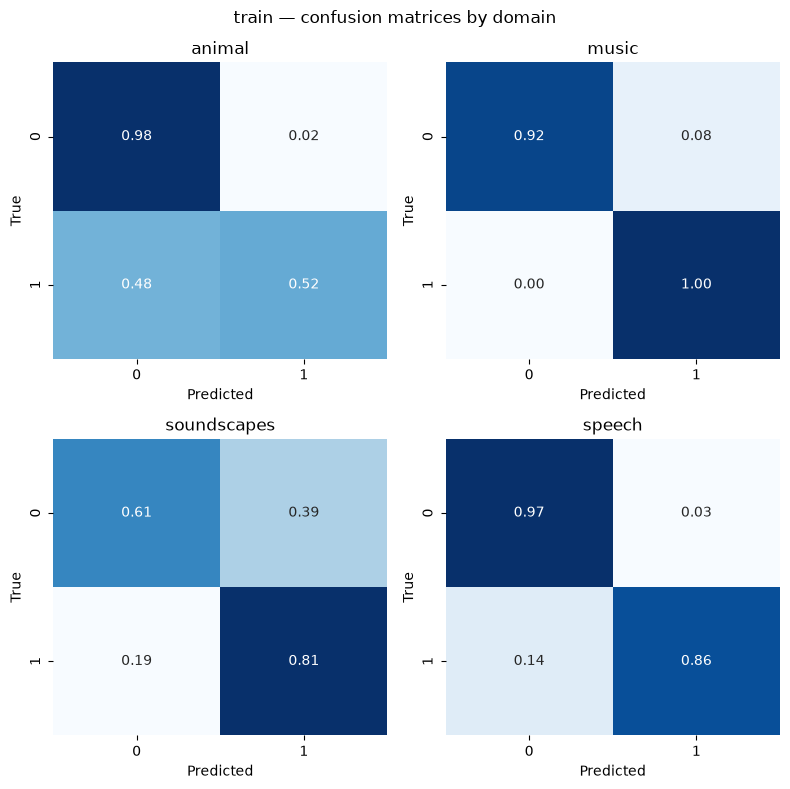

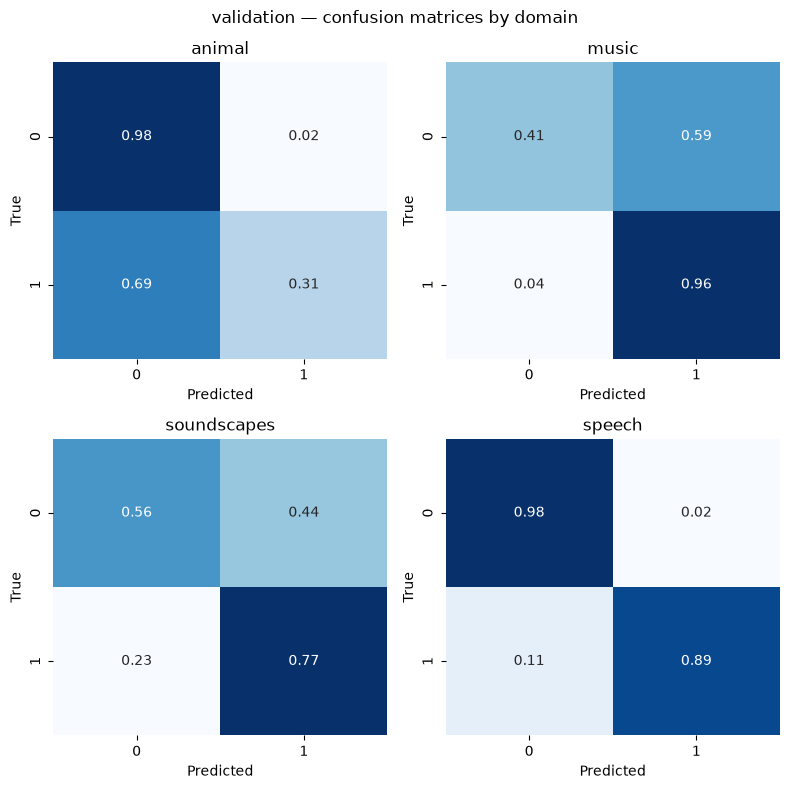

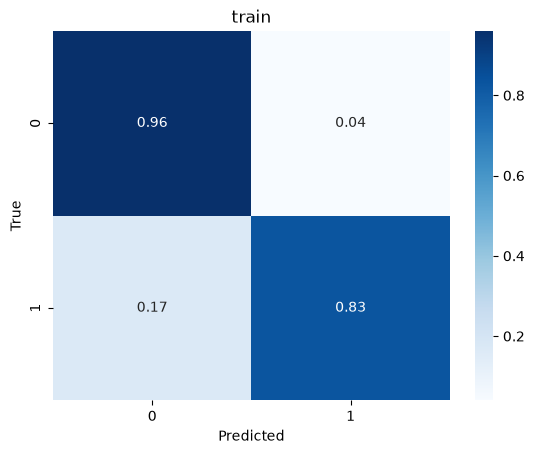

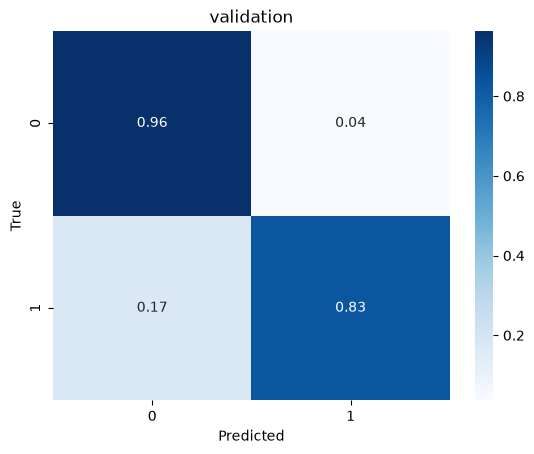

Confusion Matrices for frame_dann experiment


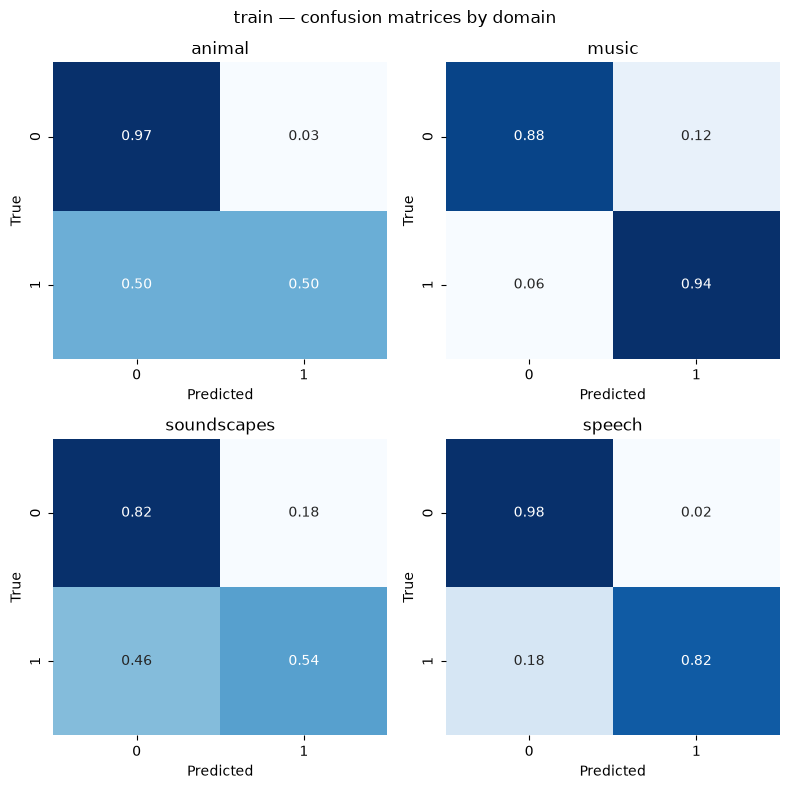

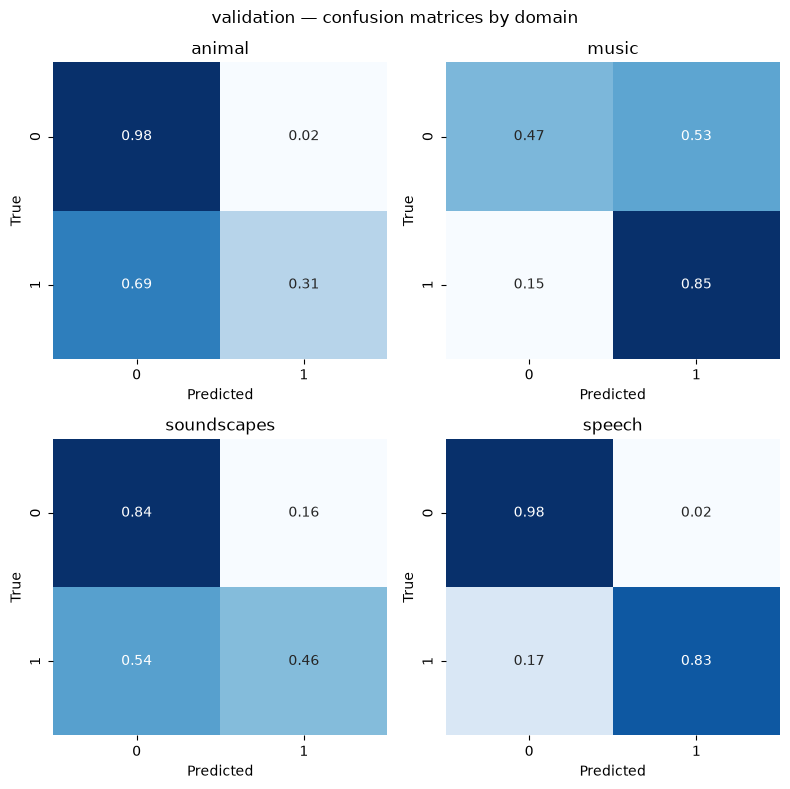

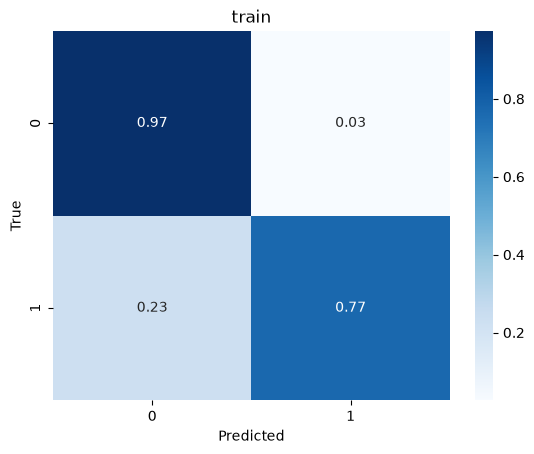

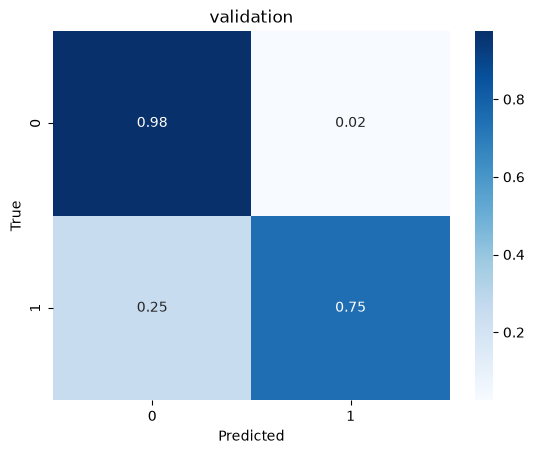

In [22]:
for run in ("frame", "frame_dann"):
    splits = [("train", f"{results_dict[run]}/train_results.pt"), ("validation", f"{results_dict[run]}/validation_results.pt")]

    conf_mat_outdir = os.path.join("outputs/plots/confusion_matrices", run)
    tables_outdir = os.path.join("outputs/tables", run)

    for d in (conf_mat_outdir, tables_outdir):
        os.makedirs(d, exist_ok=True)


    reports = evaluation.compute_classification_reports(None, splits)
    all_reports[run] = reports
    #display_classification_reports(reports)

    with open(f"outputs/tables/{run}/classification_reports.json", "w") as f:
        json.dump(reports, f, indent=2)

    print(f"Confusion Matrices for {run} experiment")
    for split_name, pt_path in splits:
        evaluation.save_combined_confusion_matrix(None, pt_path, split_name, output_dir=f"plots/confusion_matrices/{run}")

    evaluation.save_confusion_matrices(None, splits)


In [ ]:
for split_name in ("train", "validation"):
    tables = {}
    for run in ("frame", "frame_dann"):
        tables[run] = evaluation.build_summary_table(all_reports[run], split_name=split_name)

    comparison = pd.concat(tables, axis=1)
    print(split_name)
    display(comparison)
    

train


frame                                                 \
             accuracy balanced_accuracy precision_macro recall_macro   
domain                                                                 
animal       0.877069          0.746423        0.866399     0.746423   
music        0.977778          0.958561        0.983131     0.958561   
soundscapes  0.711042          0.710936        0.720419     0.710936   
speech       0.948612          0.915902        0.927983     0.915902   

                      frame_dann                                    \
             f1_macro   accuracy balanced_accuracy precision_macro   
domain                                                               
animal       0.784775   0.871946          0.737162        0.857229   
music        0.970051   0.925397          0.909104        0.897998   
soundscapes  0.707869   0.679051          0.679196        0.694646   
speech       0.921766   0.947835          0.901153        0.938679   

                                    
            recall_macro  f1_macro  
domain                              
animal          0.737162  0.774788  
music           0.909104  0.903330  
soundscapes     0.679196  0.672601  
speech          0.901153  0.918270

validation


frame                                                 \
             accuracy balanced_accuracy precision_macro recall_macro   
domain                                                                 
animal       0.881974          0.641377        0.781728     0.641377   
music        0.830986          0.687364        0.808244     0.687364   
soundscapes  0.663934          0.663934        0.671734     0.663934   
speech       0.961603          0.935071        0.943525     0.935071   

                      frame_dann                                    \
             f1_macro   accuracy balanced_accuracy precision_macro   
domain                                                               
animal       0.677671   0.881974          0.641377        0.781728   
music        0.717507   0.760563          0.661220        0.668182   
soundscapes  0.660075   0.647541          0.647541        0.671992   
speech       0.939220   0.954925          0.909635        0.945981   

                                    
            recall_macro  f1_macro  
domain                              
animal          0.641377  0.677671  
music           0.661220  0.664443  
soundscapes     0.647541  0.634552  
speech          0.909635  0.926377

FRAME


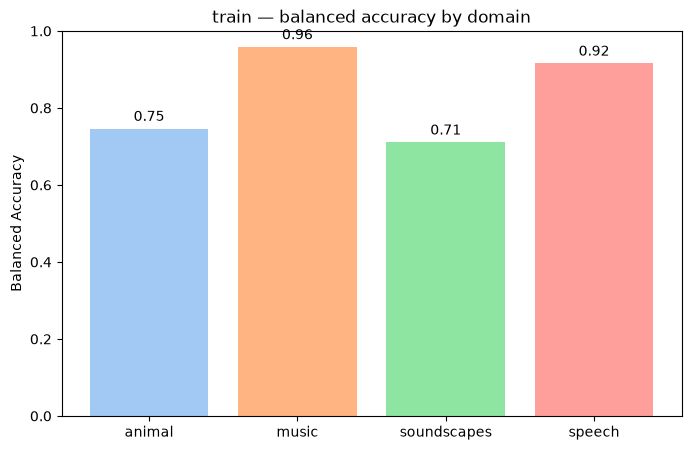

FRAME


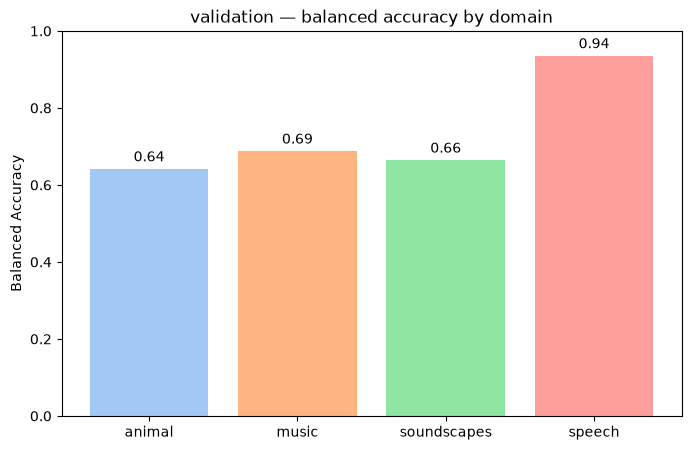

FRAME_DANN


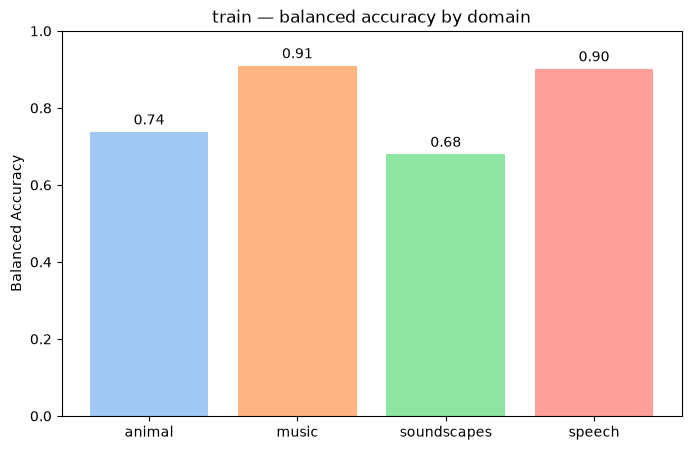

FRAME_DANN


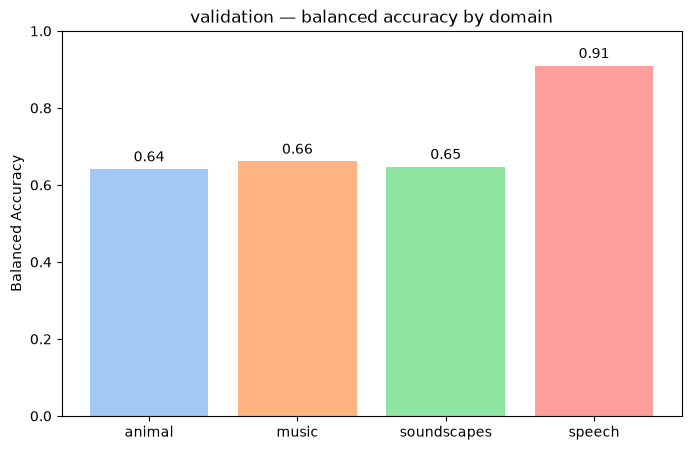

In [26]:
for run in ("frame", "frame_dann"):
    for split_name in ("train", "validation"):
        print(f"{run.upper()}")
        evaluation.plot_domain_metric_bar(all_reports[run], split_name=split_name, metric="balanced_accuracy", filename=f"plots/{run}/{split_name}_domain_summary.png")

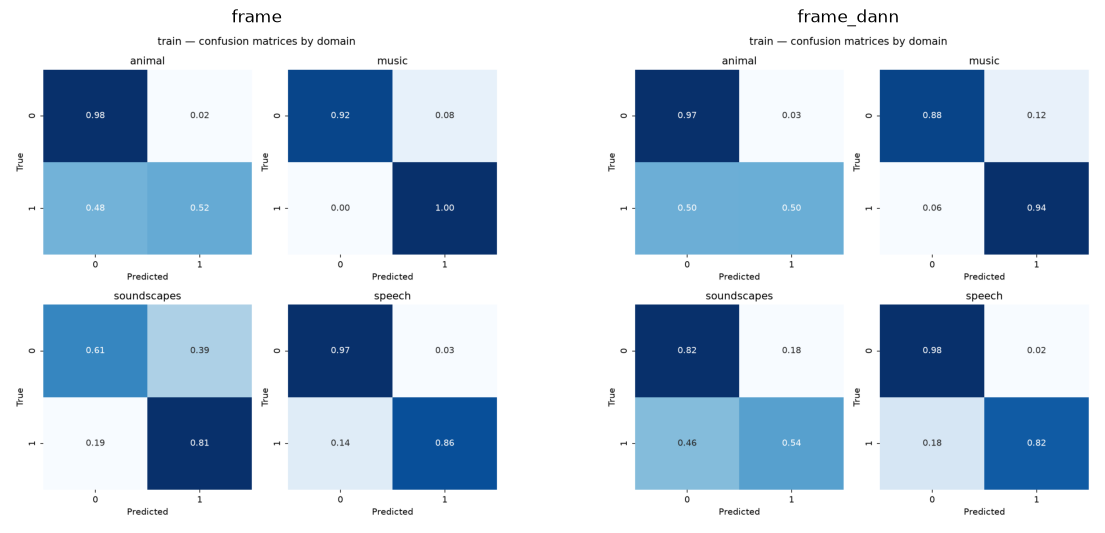

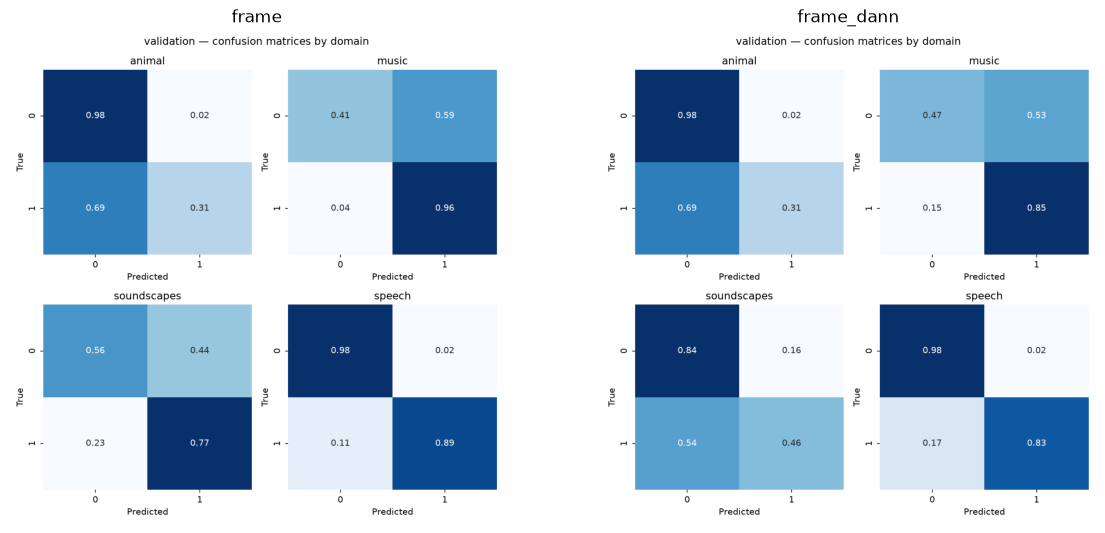

In [30]:
for split_name in ("train", "validation"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    for ax, run in zip(axes, ("frame", "frame_dann")):
        img = mpimg.imread(f"outputs/plots/confusion_matrices/{run}/{split_name}_combined_cf_matrix.png")
        ax.imshow(img)
        ax.set_title(run)
        ax.axis("off")
    plt.show()